# CAM7 FLTHIST – Period Statistics

For each variable, one figure is produced **per statistic** showing all datasets in a 2-row grid.

| Statistic | Meaning |
|-----------|---------|
| **Mean** | Time-mean |
| **Std Dev** | Time standard deviation |
| **Skewness** | Pearson moment skewness |
| **P99** | 99th-percentile over the period |
| **P01** | 1st-percentile over the period |

Cases are defined in `dcases` (label → run name).  
Optional filters: season (DJF/MAM/JJA/SON) and lat/lon region.  
Maps display 0–360° longitude.

In [1]:
import glob
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeatureL
from cartopy.util import add_cyclic_point
from pathlib import Path
from collections import OrderedDict
from IPython.display import Image, display as ipy_display

# ── Shapely 2.x / cartopy compatibility fix ───────────────────────────────────
from shapely.geometry.base import BaseMultipartGeometry
if not hasattr(BaseMultipartGeometry, '__getitem__'):
    BaseMultipartGeometry.__getitem__ = lambda self, i: self.geoms[i]
# ─────────────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'font.size': 10})

In [2]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [3]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc108.hpc.ucar.edu/19080/proxy/8787/status,
Dashboard: /node/crhtc108.hpc.ucar.edu/19080/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.216:44775,Workers: 0
Dashboard: /node/crhtc108.hpc.ucar.edu/19080/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


---
## Options

In [4]:
# ── Paths ───────────────────────────────────────────────────────────────────
ARCHIVE_DIR = Path('/glade/derecho/scratch/rneale/archive')
ERA5_PRECIP = Path('/glade/derecho/scratch/rneale/ERA5/dmean/1deg/precip_era5_dmean_1x1.nc')
TRMM_PATH   = Path('/glade/campaign/cgd/amp/rneale/data/TRMM/daily/1deg/3B42.1998-2013.daily.1deg.v7.nc')
DIR_FIG     = Path('/glade/u/home/rneale/python/python-figs/papers/ZM_PBL')

# ── Cases ───────────────────────────────────────────────────────────────────
dcases = {
    'CAM6'             : 'f.e22.FHIST.f09_f09.CAM6.L32.000',
    'CAM7-CAM6phys'    : 'f.e30.FHIST.CAM6-phys.L32.000a',
    'CAM7'             : 'f.e30.FLTHIST.CAM7.L58.000a',
    'CAM7-L32'         : 'f.e30.FLTHIST.CAM7.L32.000a',
    'CAM7-nozmpbl'     : 'f.e30.FLTHIST.CAM7.L58.001a',
    'CAM7-nozmpbl-L32' : 'f.e30.FLTHIST.CAM7.L32.001a',
}
CASES       = list(dcases.values())
CASE_LABELS = list(dcases.keys())

# ── History stream per case (default h1a; override where different) ──────────
CASE_HIST = {
    'CAM6': 'h1',   # CAM6 wrote daily output to h1, not h1a
}

# ── Common analysis period ───────────────────────────────────────────────────
YEAR_START = 1990
YEAR_END   = 1999

# ── Season and region filters ────────────────────────────────────────────────
SEASON     = 'JJA'          # 'DJF', 'MAM', 'JJA', 'SON', or None for all seasons
LAT_BOUNDS = (-25.,35.)     # (lat_min, lat_max) e.g. (-30, 30) for tropics; None = global
LON_BOUNDS = (0.,360.)      # (lon_min, lon_max); None = global

# ── Variable configuration ───────────────────────────────────────────────────
VAR_CONFIG = {
#    'PRECT':    {'scale': 86400*1000, 'units': 'mm day⁻¹',    'cmap': 'terrain_r',   'lev': None},
    'PRECC':    {'scale': 86400*1000, 'units': 'mm day⁻¹',    'cmap': 'Blues',   'lev': None},
    'SWCF':    {'scale': 1., 'units': 'W m⁻¹',    'cmap': 'RdBu',   'lev': None},
#    'CAPE':     {'scale': 1,          'units': 'J kg⁻¹',      'cmap': 'YlOrRd', 'lev': None},
#    'FLUT':     {'scale': 1,          'units': 'W m⁻²',       'cmap': 'hot_r',  'lev': None},
#    'OMEGA500': {'scale': 864,        'units': 'hPa day⁻¹',   'cmap': 'RdBu_r', 'lev': None},
#    'ZMDT':     {'scale': 86400,      'units': 'K day⁻¹',     'cmap': 'RdBu_r', 'lev': 850},
#    'ZMMU':     {'scale': 86400,      'units': 'kg m⁻² day⁻¹','cmap': 'YlOrRd', 'lev': 850},
}

# ── Obs sources for PRECT  (order controls subplot order) ────────────────────
PRECT_OBS = OrderedDict([
    ('TRMM', (TRMM_PATH,  'precip',  1.)),
    ('ERA5', (ERA5_PRECIP, 'tp',     24 * 1000.)),
])
OBS_YEARS = {'ERA5': (YEAR_START, YEAR_END), 'TRMM': (2000, 2009)}

# ── Variables to process ─────────────────────────────────────────────────────
VARS_TO_PLOT = ['PRECC']

print('Cases:', CASE_LABELS)
print(f'Period: {YEAR_START}–{YEAR_END}')
print(f'Season: {SEASON or "all"}   Lat: {LAT_BOUNDS or "global"}   Lon: {LON_BOUNDS or "global"}')
print('Variables:', VARS_TO_PLOT)

Cases: ['CAM6', 'CAM7-CAM6phys', 'CAM7', 'CAM7-L32', 'CAM7-nozmpbl', 'CAM7-nozmpbl-L32']
Period: 1990–1999
Season: JJA   Lat: (-25.0, 35.0)   Lon: (0.0, 360.0)
Variables: ['PRECC']


---
## Helper functions

In [5]:
def get_cam_files(case, year_start, year_end, hist_stream='h1a'):
    """Return sorted list of daily hist files for the given case and year range."""
    hist_dir = ARCHIVE_DIR / case / 'atm' / 'hist'
    files = []
    for yr in range(year_start, year_end + 1):
        files.extend(sorted(hist_dir.glob(f'{case}.cam.{hist_stream}.{yr}-*.nc')))
    return sorted(files)


def xr_skewness(da, dim='time'):
    """Biased Pearson moment skewness along *dim*."""
    mean = da.mean(dim)
    std  = da.std(dim)
    return ((da - mean) ** 3).mean(dim) / std ** 3


def _filter_da(da):
    """Apply SEASON and LAT_BOUNDS/LON_BOUNDS filters to a time-resolved DataArray."""
    if SEASON is not None:
        da = da.isel(time=(da.time.dt.season == SEASON).values)
    if LAT_BOUNDS is not None:
        lat0, lat1 = min(LAT_BOUNDS), max(LAT_BOUNDS)
        da = da.where((da.lat >= lat0) & (da.lat <= lat1), drop=True)
    if LON_BOUNDS is not None:
        lon0, lon1 = LON_BOUNDS
        if lon0 < 0 and da.lon.values.min() >= 0:
            lon0, lon1 = lon0 + 360, lon1 + 360
        da = da.where((da.lon >= lon0) & (da.lon <= lon1), drop=True)
    return da


def _drop_quantile(da):
    """Drop the scalar 'quantile' coordinate xarray adds after .quantile()."""
    if 'quantile' in da.coords:
        da = da.drop_vars('quantile')
    return da


# ── Colormap utilities ────────────────────────────────────────────────────────
def make_white_cmap(cmap_name, white_frac=0.08):
    """Return a copy of cmap_name with the lowest white_frac set to pure white."""
    base  = plt.get_cmap(cmap_name)
    rgba  = base(np.linspace(0, 1, 256))
    n     = max(1, int(256 * white_frac))
    rgba[:n] = [1., 1., 1., 1.]
    return mcolors.LinearSegmentedColormap.from_list(f'{cmap_name}_w0', rgba)

PRECIP_BLUES = make_white_cmap('Blues',   0.06)
PRECIP_GNBU  = make_white_cmap('GnBu',   0.06)
PRECIP_YG_W  = make_white_cmap('YlGnBu', 0.10)
# ─────────────────────────────────────────────────────────────────────────────


STAT_FUNCS = OrderedDict([
    ('Mean',    lambda da: da.mean('time')),
    ('Std Dev', lambda da: da.std('time')),
    ('Skewness',lambda da: xr_skewness(da, 'time')),
    ('P99',     lambda da: _drop_quantile(da.quantile(0.99, dim='time'))),
    ('P01',     lambda da: _drop_quantile(da.quantile(0.01, dim='time'))),
])
STATS = list(STAT_FUNCS.keys())


def _compute_clim(arrays, stat_name, base_cmap):
    """Robust color limits and colormap for one statistic across all datasets."""
    all_vals = np.concatenate(
        [a.values.ravel() for a in arrays if a is not None]
    )
    all_vals = all_vals[np.isfinite(all_vals)]
    if len(all_vals) == 0:
        return -1., 1., 'RdBu_r'
    if stat_name == 'Mean':
        v = np.nanpercentile(np.abs(all_vals), 98)
#        v = 25.
        return 0., v, 'terrain_r'   
    if stat_name == 'Skewness':
        v = np.nanpercentile(np.abs(all_vals), 98)
#        v = 20.
        return 0., v, 'coolwarm'
    if stat_name == 'Std Dev':
        v = np.nanpercentile(all_vals, 98)
#        v = 25.
        return 0., v, 'terrain_r'
    if stat_name == 'P99':
        v = np.nanpercentile(all_vals, 98)
#        v = 100.
        return 0., v, 'terrain_r'
    if stat_name == 'P01':
        v = np.nanpercentile(all_vals, 98)
#        v = 0.2
        return 0., v, 'terrain_r'
    if base_cmap == 'RdBu_r':
        v = np.nanpercentile(np.abs(all_vals), 98)
        return -v, v, 'RdBu_r'
    return (np.nanpercentile(all_vals, 2),
            np.nanpercentile(all_vals, 98),
            base_cmap)


STAT_UNITS_SUFFIX = {
    'Mean':     '',
    'Std Dev':  '',
    'Skewness': ' (–)',
    'P99':      '',
    'P01':      '',
}

print('Helper functions defined.')
print('Colormap options: PRECIP_BLUES, PRECIP_GNBU, PRECIP_YG_W (or any matplotlib name)')

Helper functions defined.
Colormap options: PRECIP_BLUES, PRECIP_GNBU, PRECIP_YG_W (or any matplotlib name)


---
## Compute CAM statistics

Opens all h1a files lazily via dask, then computes each statistic in turn.  
Results are stored in `all_stats[vname][case_label][stat_name]`.

In [6]:
# all_stats[vname][case_label][stat_name] = DataArray(lat, lon)
all_stats = {v: {} for v in VARS_TO_PLOT}

for vname in VARS_TO_PLOT:
    cfg   = VAR_CONFIG[vname]
    scale = cfg['scale']
    lev_p = cfg['lev']
    lev_info = f'@ {lev_p} hPa (nearest)' if lev_p else '2D surface field'
    print(f'\n── {vname}  ({lev_info}) ──────────────────────────')

    for case, label in zip(CASES, CASE_LABELS):
        hist_stream = CASE_HIST.get(label, 'h1a')
        files = get_cam_files(case, YEAR_START, YEAR_END, hist_stream)
        if not files:
            print(f'  {label}: no files found ({hist_stream}) — skipping')
            all_stats[vname][label] = None
            continue
        print(f'  {label}: {len(files)} files', end='  ', flush=True)

        ds = xr.open_mfdataset(
            files,
            combine='by_coords',
            data_vars='minimal', coords='minimal',
            compat='override', join='override',
            parallel=True, chunks={'time': 50},
        )
        da = ds[vname] * scale
        if lev_p is not None:
            da = da.sel(lev=lev_p, method='nearest')
        da = _filter_da(da)

        case_stats = {}
        for stat_name, fn in STAT_FUNCS.items():
            case_stats[stat_name] = fn(da).compute()
        all_stats[vname][label] = case_stats
        ds.close()

        mean_val = float(case_stats['Mean'].mean())
        n_t = da.sizes['time']
        print(f'global mean = {mean_val:.3g} {cfg["units"]}  ({n_t} timesteps)')

print('\nDone.')


── PRECC  (2D surface field) ──────────────────────────
  CAM6: 365 files  global mean = 2.32 mm day⁻¹  (920 timesteps)
  CAM7-CAM6phys: 365 files  global mean = 2.26 mm day⁻¹  (920 timesteps)
  CAM7: 365 files  global mean = 2.39 mm day⁻¹  (920 timesteps)
  CAM7-L32: 365 files  global mean = 2.29 mm day⁻¹  (920 timesteps)
  CAM7-nozmpbl: 365 files  global mean = 1.73 mm day⁻¹  (920 timesteps)
  CAM7-nozmpbl-L32: 365 files  global mean = 2.25 mm day⁻¹  (920 timesteps)

Done.


---
## Load observation statistics

ERA5 `tp` is the daily-mean of hourly accumulations (m/hr equivalent); ×24×1000 = mm/day.  
TRMM `precip` is already in mm/day.

In [7]:
# obs_stats[vname][obs_name][stat_name] = DataArray(lat, lon)
obs_stats = {}

if 'PRECT' in VARS_TO_PLOT:
    obs_stats['PRECT'] = {}
    for obs_name, (fpath, obs_var, obs_scale) in PRECT_OBS.items():
        yr0, yr1 = OBS_YEARS[obs_name]
        print(f'  {obs_name}  ({yr0}–{yr1})  var={obs_var}  scale={obs_scale}x')
        ds = xr.open_dataset(fpath, chunks={'time': 100})
        da = ds[obs_var].astype('float32') * obs_scale
        if obs_name == 'TRMM':
            da = da.assign_coords(lon=(da.lon.values + 180) % 360).sortby('lon')
        try:
            da = da.sel(time=slice(str(yr0), str(yr1)))
        except Exception:
            pass
        da = _filter_da(da)
        stat_dict = {}
        for stat_name, fn in STAT_FUNCS.items():
            stat_dict[stat_name] = fn(da).compute()
        obs_stats['PRECT'][obs_name] = stat_dict
        ds.close()
        mean_val = float(stat_dict['Mean'].mean())
        print(f'    global mean = {mean_val:.3g} mm/day  ({da.sizes["time"]} days)')

print('\nDone loading obs.')


Done loading obs.


---
## Plot

One figure per statistic per variable.  All datasets shown as columns so they can be compared side-by-side.  Color limits are shared across all datasets for each statistic.  Skewness always uses RdBu_r; Std Dev uses YlOrBr; all others use the variable's default colormap.

In [8]:
def plot_stat(vname, stat_name, show=True):
    """One figure per statistic: obs first (row 1) then all model cases below."""
    cfg = VAR_CONFIG[vname]

    # ── obs first, then ALL model cases (None = no-data placeholder) ─────────
    datasets = []
    if vname in obs_stats:
        for obs_name, sd in obs_stats[vname].items():
            datasets.append((obs_name, sd[stat_name]))
    for label in CASE_LABELS:
        da = all_stats[vname].get(label)
        datasets.append((label, da[stat_name] if da is not None else None))

    n_ds   = len(datasets)
    n_cols = 2
    n_rows = int(np.ceil(n_ds / n_cols))

    # color limits from datasets that actually have data
    arrs = [da for _, da in datasets if da is not None]
    if not arrs:
        print(f'  No data for {vname}/{stat_name} — skipping.')
        return
    vmin, vmax, cmap = _compute_clim(arrs, stat_name, cfg['cmap'])

    # panel_h: 25% shorter than original; overall figure scaled up 25%
    if LAT_BOUNDS is None:
        panel_h = 2.2 * 0.75
    else:
        lat_span = max(LAT_BOUNDS) - min(LAT_BOUNDS)
        panel_h  = max(4.4 * lat_span / 180.0, 1.4) * 0.75
    panel_w = 4.5

    proj = ccrs.PlateCarree(central_longitude=180)

    fig_w = panel_w * n_cols * 1.25
    fig_h = (panel_h * n_rows + 0.9) * 1.1
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(fig_w, fig_h),
        subplot_kw={'projection': proj},
    )
    axes_flat = np.array(axes).ravel()
    # hide trailing empty slots beyond n_ds
    for ai in range(n_ds, n_rows * n_cols):
        axes_flat[ai].set_visible(False)

    lat0_e = min(LAT_BOUNDS) if LAT_BOUNDS else  -90.
    lat1_e = max(LAT_BOUNDS) if LAT_BOUNDS else   90.
    lon0_e = (min(LON_BOUNDS) if LON_BOUNDS else   0.) - 180.
    lon1_e = (max(LON_BOUNDS) if LON_BOUNDS else 360.) - 180.

    last_im = None
    for ai, (label, da) in enumerate(datasets):
        ax = axes_flat[ai]

        if da is None:
            # grey placeholder panel for a case with no data
            ax.set_extent([lon0_e, lon1_e, lat0_e, lat1_e], crs=proj)
            ax.coastlines(linewidth=0.4, color='#aaaaaa')
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, color='#888888')
            ax.set_title(label, fontsize=9, fontweight='bold', pad=3)
            continue

        lat = da.lat.values
        lon = da.lon.values

        lon_span = float(lon.max() - lon.min())
        if lon_span > 350:
            try:
                data_plot, lon_plot = add_cyclic_point(da.values, coord=lon)
            except Exception:
                data_plot, lon_plot = da.values, lon
        else:
            data_plot, lon_plot = da.values, lon

        im = ax.pcolormesh(
            lon_plot, lat, data_plot,
            vmin=vmin, vmax=vmax, cmap=cmap,
            transform=ccrs.PlateCarree(),
            rasterized=True,
        )

        if LAT_BOUNDS is None and LON_BOUNDS is None:
            ax.set_global()
        else:
            ax.set_extent([lon0_e, lon1_e, lat0_e, lat1_e], crs=proj)

        ax.coastlines(linewidth=0.4, color='#333333')
        ax.set_title(label, fontsize=9, fontweight='bold', pad=3)
        last_im = im

    # ── shared colorbar ───────────────────────────────────────────────────────
    units_str = cfg['units'] + STAT_UNITS_SUFFIX[stat_name]
    fig.subplots_adjust(top=0.90, bottom=0.08, hspace=0.08, wspace=0.05)
    cbar_ax = fig.add_axes([0.25, 0.02, 0.50, 0.020])
    cbar = fig.colorbar(last_im, cax=cbar_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(units_str, fontsize=9)

    lev_str    = f' @ {cfg["lev"]} hPa' if cfg['lev'] else ''
    season_str = f' {SEASON}' if SEASON else ''
    lat_str    = f' {min(LAT_BOUNDS)}–{max(LAT_BOUNDS)}°' if LAT_BOUNDS else ''
    fig.suptitle(
        f'{vname}{lev_str}  –  {stat_name}{season_str}{lat_str}  ({YEAR_START}–{YEAR_END})',
        fontsize=11, fontweight='bold', y=0.97,
    )

    lev_tag    = f'_{cfg["lev"]}hPa' if cfg['lev'] else ''
    season_tag = f'_{SEASON}' if SEASON else ''
    lat_tag    = f'_{min(LAT_BOUNDS)}to{max(LAT_BOUNDS)}' if LAT_BOUNDS else ''
    stat_tag   = stat_name.lower().replace(' ', '_')
    fpath = DIR_FIG / f'cam7_stats_{vname}{lev_tag}_{stat_tag}{season_tag}{lat_tag}_{YEAR_START}-{YEAR_END}.png'
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved: {fpath}')
    if show:
        ipy_display(Image(str(fpath)))

print('plot_stat() defined.')

plot_stat() defined.



── PRECC ──────────────────────────────────────────
  Mean
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_stats_PRECC_mean_JJA_-25.0to35.0_1990-1999.png


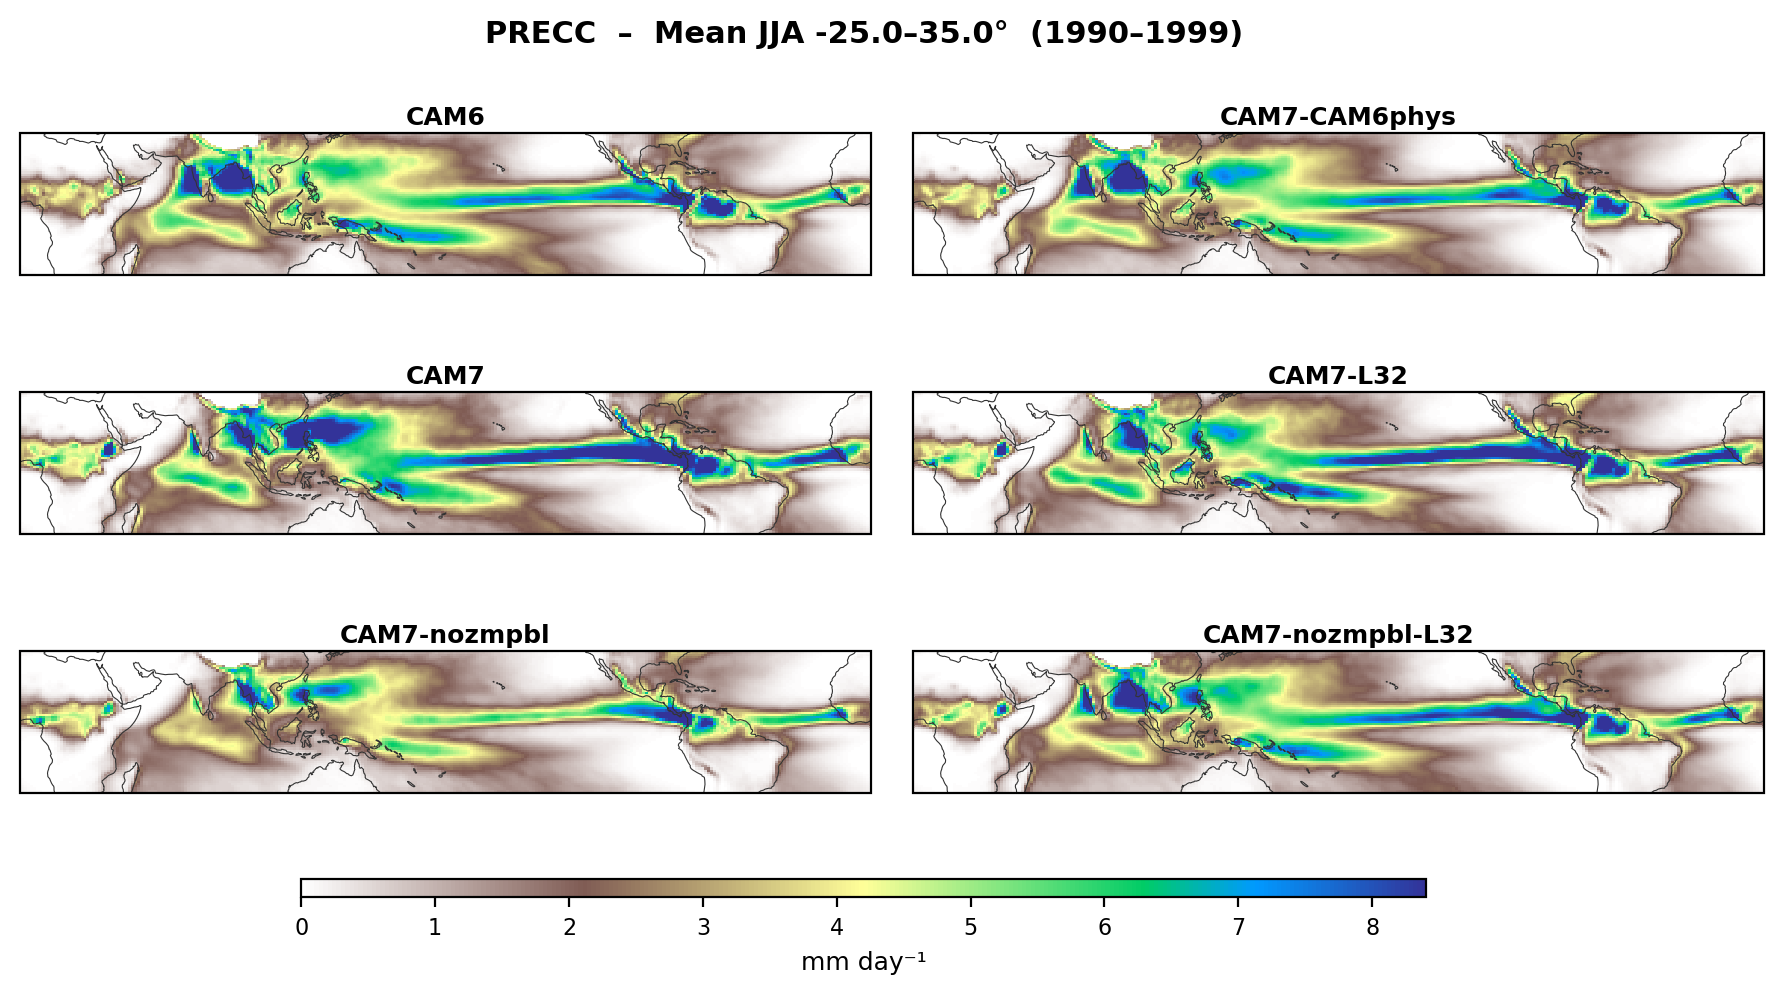

  Std Dev
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_stats_PRECC_std_dev_JJA_-25.0to35.0_1990-1999.png


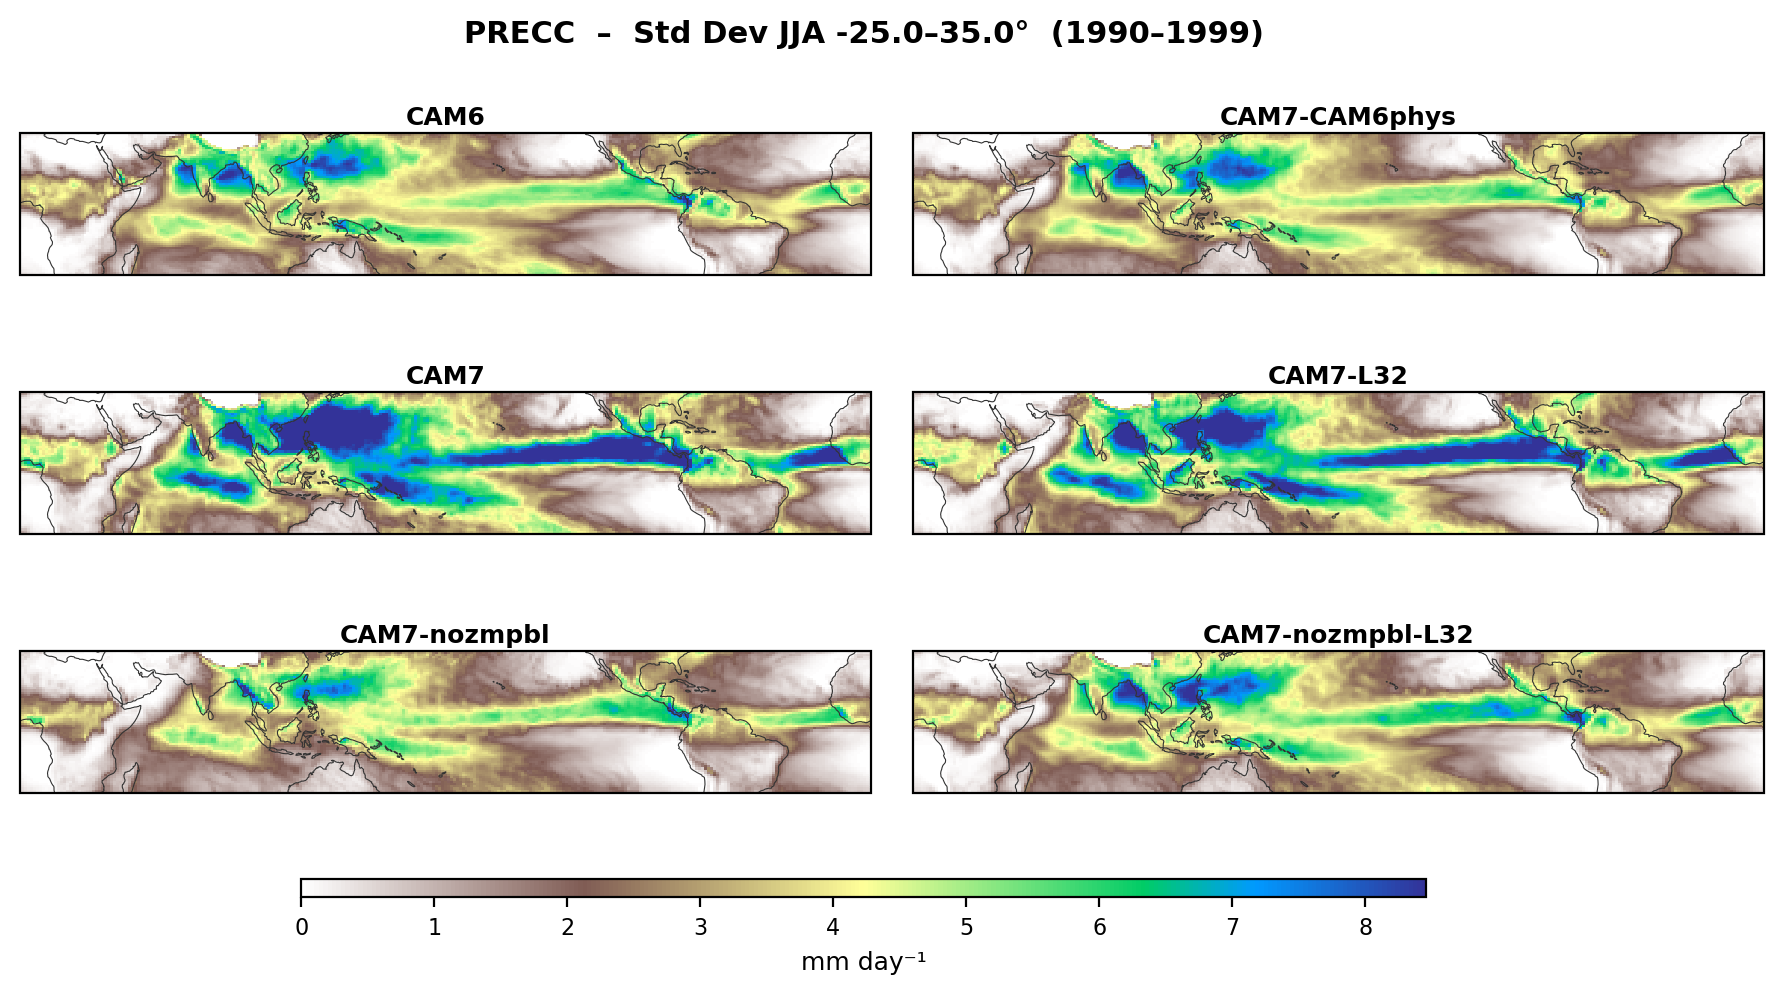

  Skewness
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_stats_PRECC_skewness_JJA_-25.0to35.0_1990-1999.png


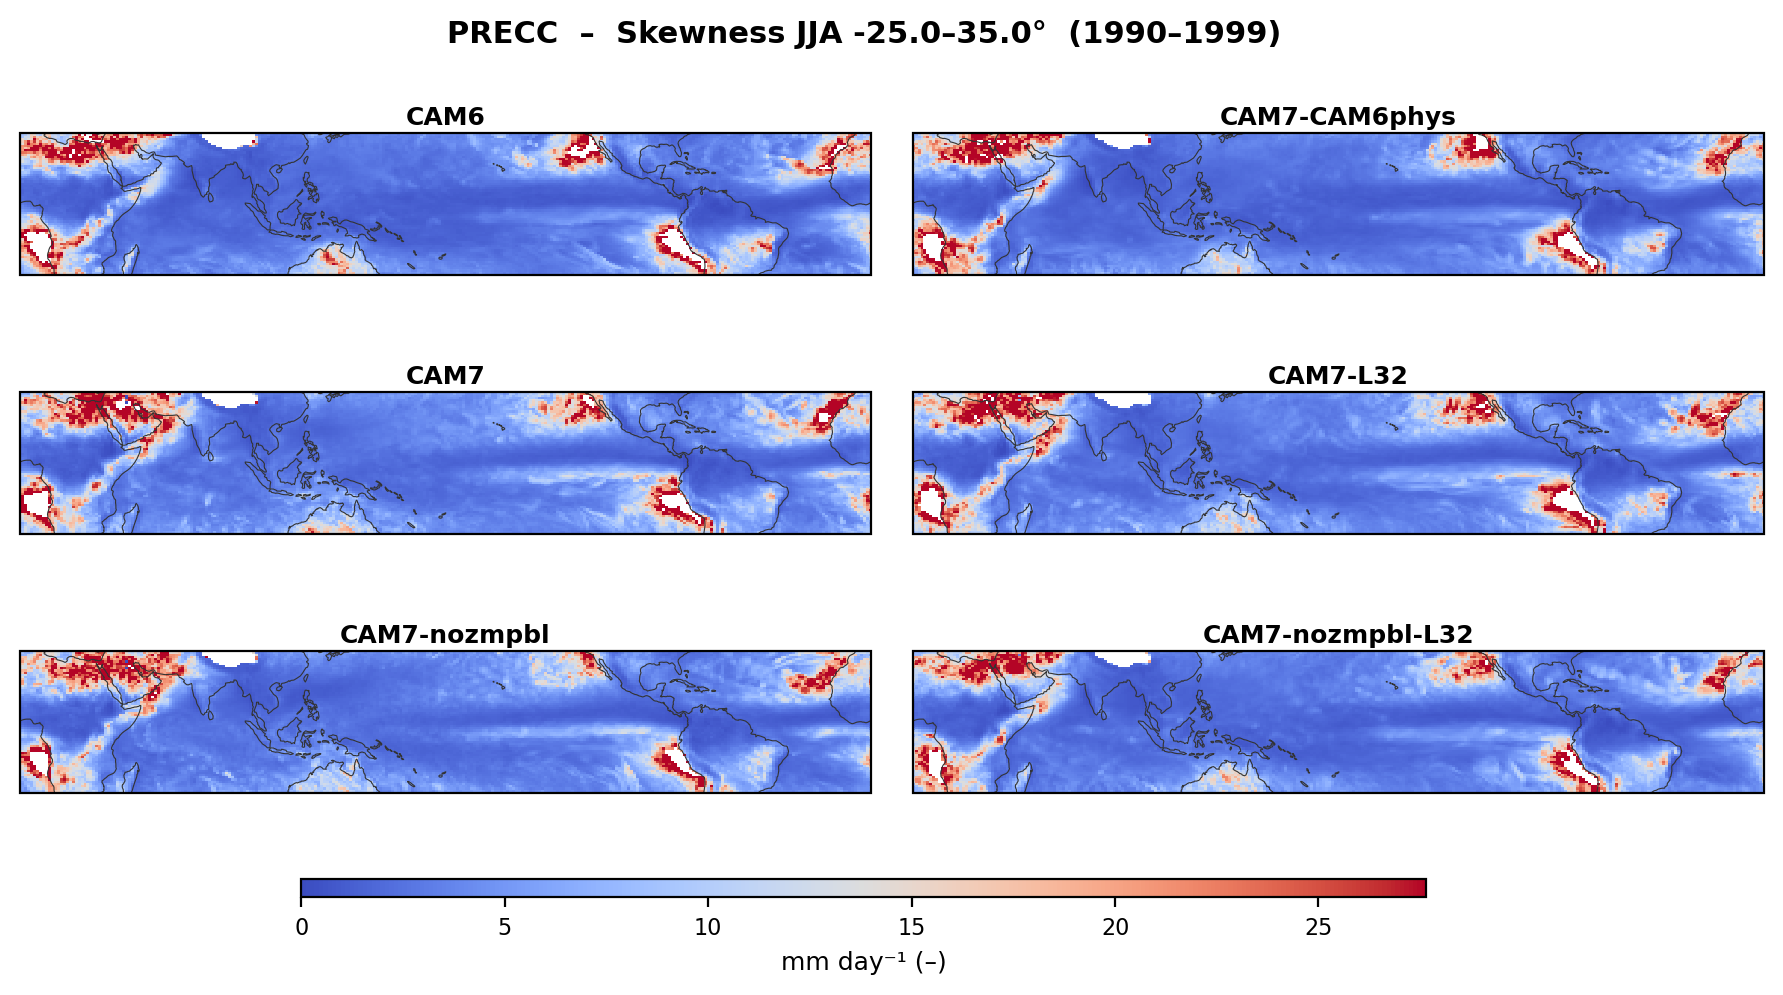

  P99
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_stats_PRECC_p99_JJA_-25.0to35.0_1990-1999.png


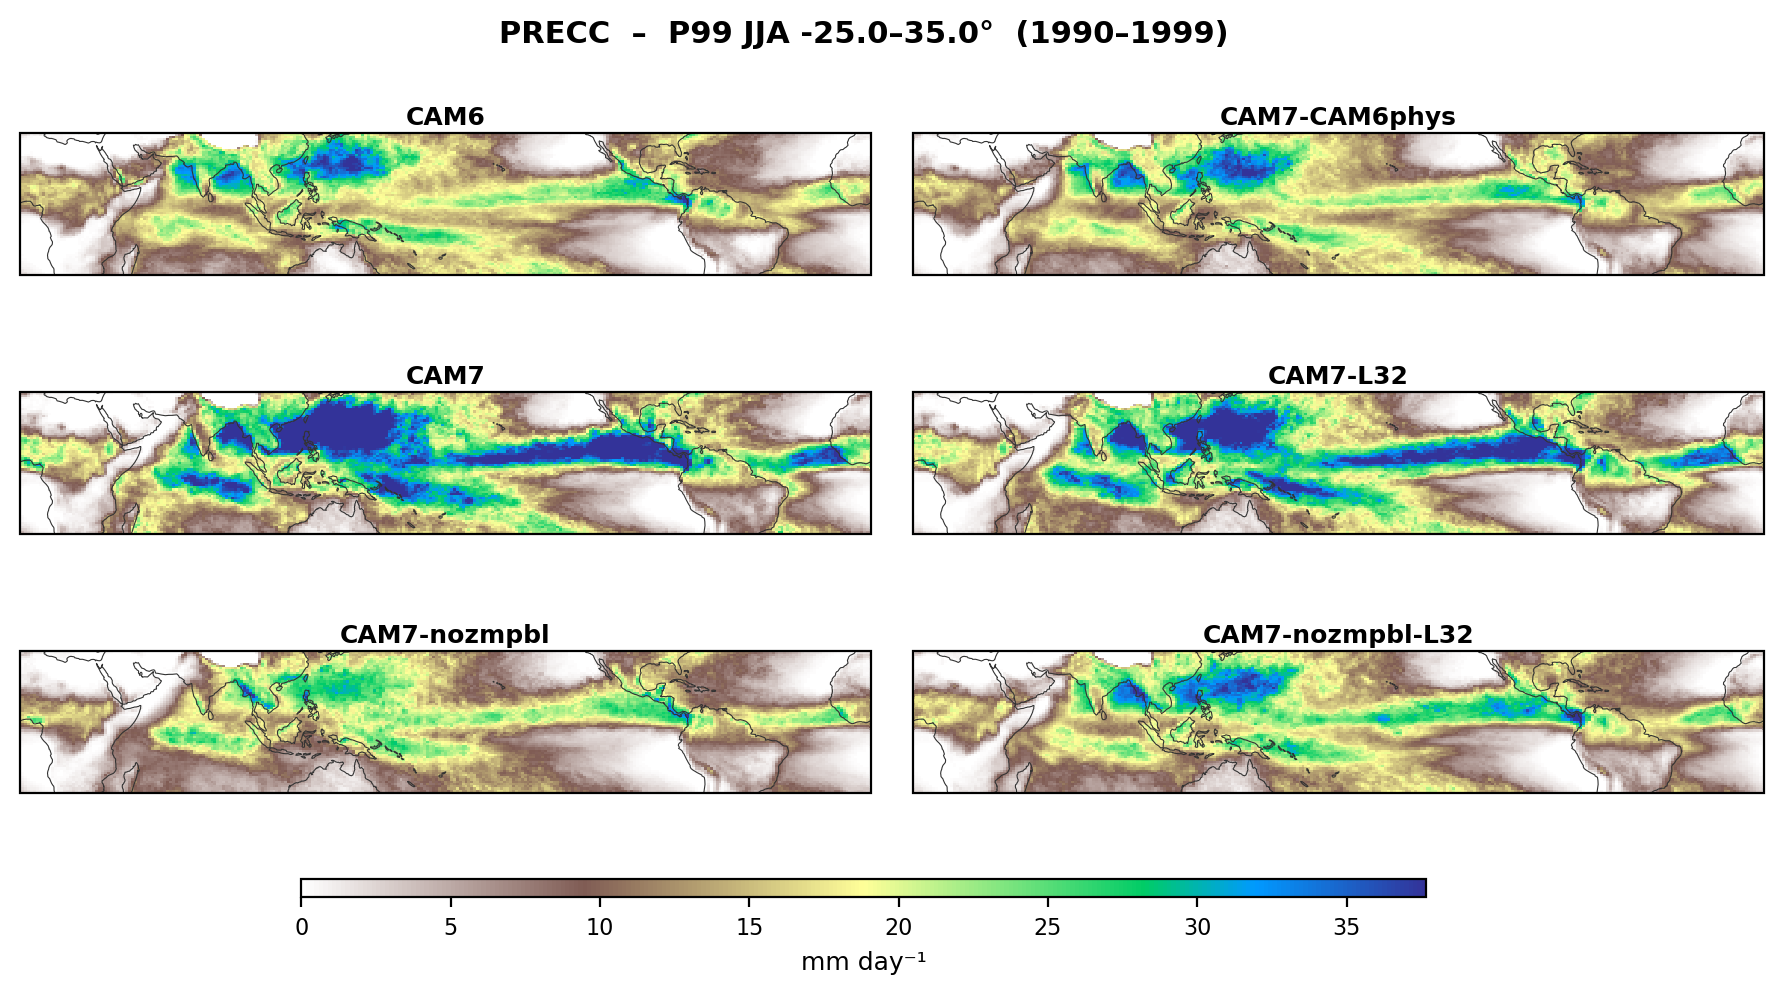

  P01
  Saved: /glade/u/home/rneale/python/python-figs/papers/ZM_PBL/cam7_stats_PRECC_p01_JJA_-25.0to35.0_1990-1999.png


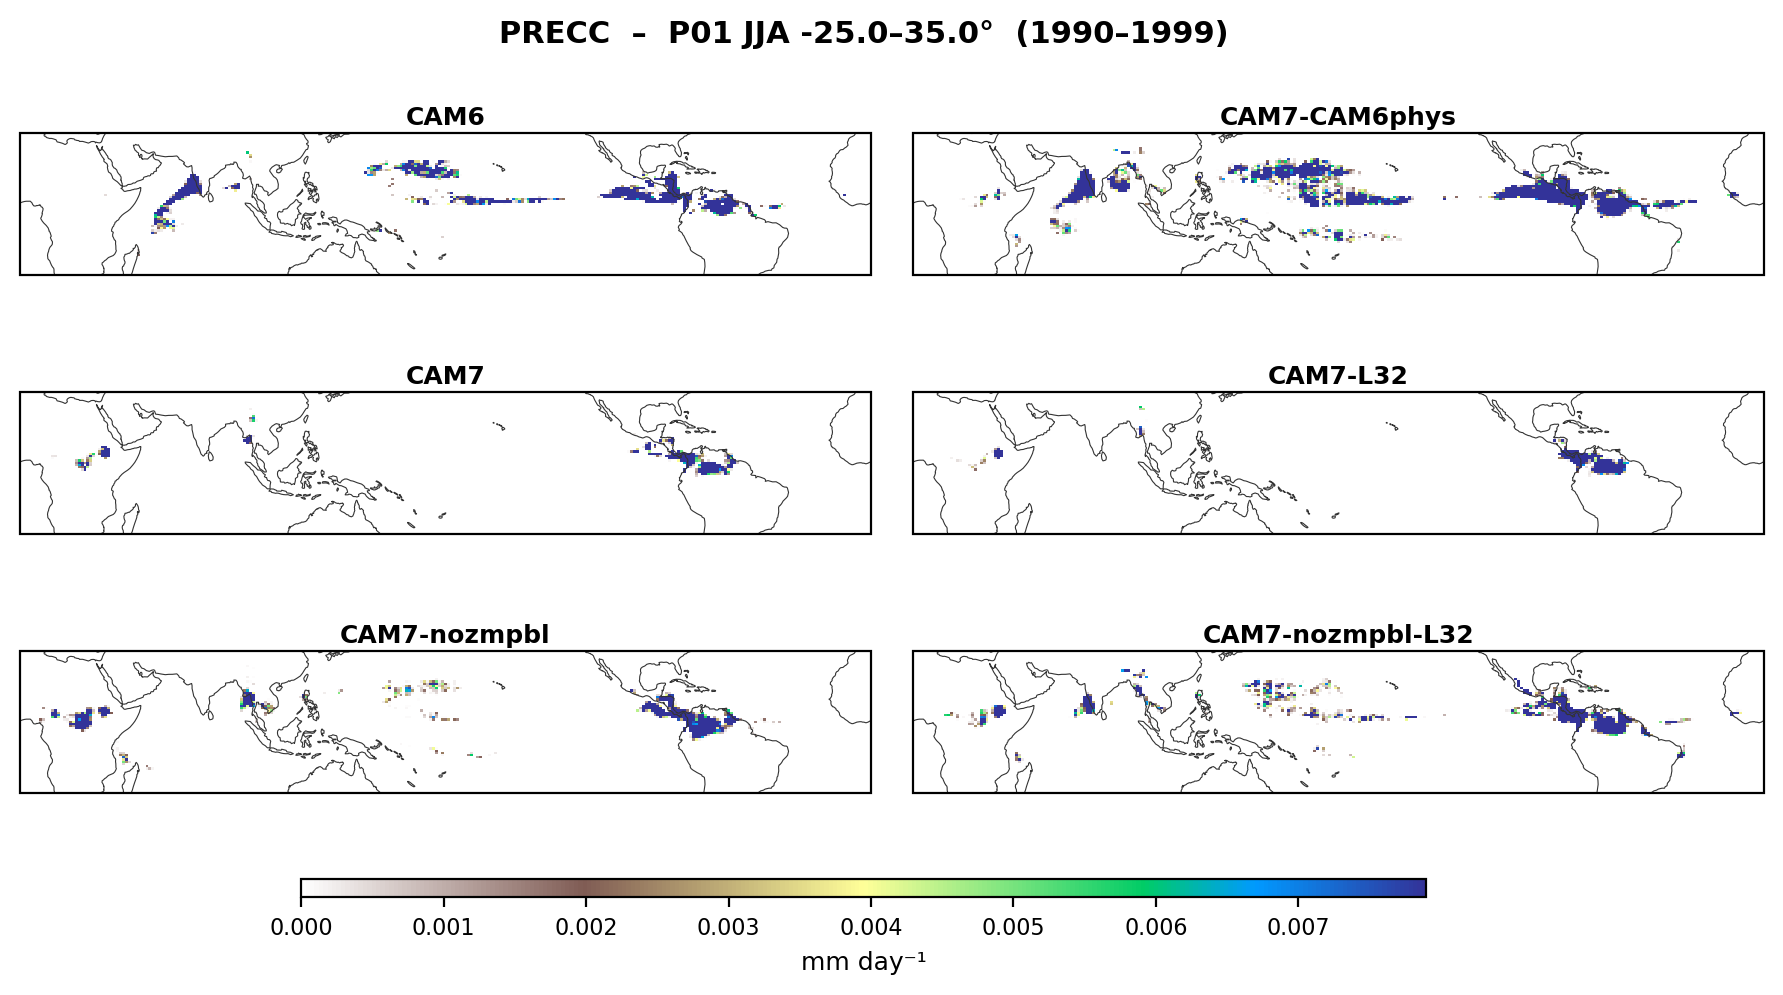

In [9]:
for vname in VARS_TO_PLOT:
    print(f'\n── {vname} ──────────────────────────────────────────')
    for stat_name in STATS:
        print(f'  {stat_name}')
        plot_stat(vname, stat_name, show=True)